# Neoclassical tearing mode
Use the **Python (FAITH labelmaker)** kernel. Change `shot` and `source` below.
Labels use 50 ms bins and 20 rho bins: gray = 0, white = unknown.


In [ ]:
from labeler.events.notebooks import load_shot, plot_shot

shot = 140004
source = "format/shots"
grid = load_shot("neoclassical_tearing_mode", shot, source=source)
grid["categories"]

### Original labels
Original annotations before class merging or 50 ms aggregation.

In [ ]:
import matplotlib.pyplot as plt
import yaml

from labeler.config import Paths
from labeler.events.source_formatters import read_tm_h5, read_tm_tar

event, shot = grid["event"], grid["shot"]
root = Paths.from_env().label_tables
manifest = yaml.safe_load((root / "events.yaml").read_text())
spec = next(row for row in manifest["format_datasets"] if row["name"] == event)
raw = {row["stem"]: root / row["path"] for row in manifest["raw_datasets"]}
paths = {stem: raw[stem] for stem in spec["sources"]}
traces = []
for stem, reader in [
    ("tm_labels_h5", read_tm_h5),
    ("tm_labels_archive", read_tm_tar),
]:
    if stem in paths:
        trace = next(iter(reader(paths[stem], shots=[shot])), None)
        if trace is not None:
            traces.append((stem, trace))
if not traces:
    print(f"No original tearing labels for shot {shot}")
else:
    fig, axes = plt.subplots(
        len(traces),
        1,
        figsize=(10, 2.5 * len(traces)),
        sharex=True,
        squeeze=False,
        layout="constrained",
    )
    for ax, (stem, (_, times, labels, _)) in zip(axes[:, 0], traces, strict=True):
        ax.plot(times, labels, linewidth=0.8)
        ax.set(
            ylabel="Binary label",
            yticks=[0, 1],
            ylim=(-0.05, 1.1),
            title=f"Shot {shot} — original {stem}",
        )
    axes[-1, 0].set_xlabel("Time (ms; original samples)")
    plt.show()

### Formatted labels
The saved grid uses 50 ms bins, with each label broadcast over 20 rho bins.

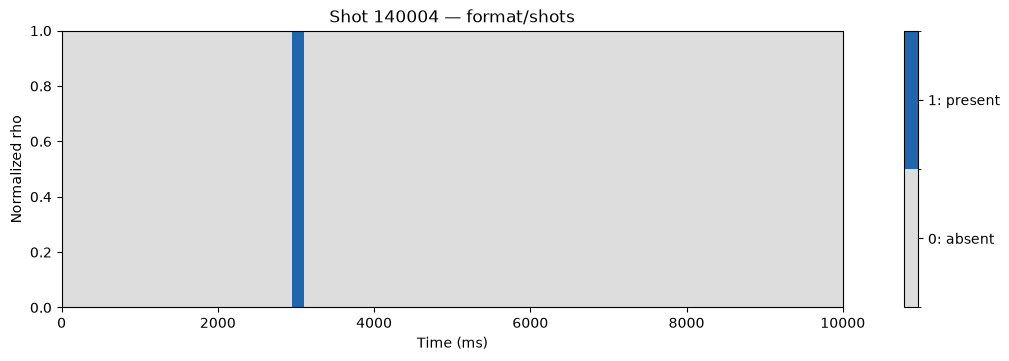

In [3]:
plot_shot(grid);

When extended labels are available, set `source` to `extend_<producer>/<shot-list>`.